# Barcelona - Average Age of Population by Census Section (2023)

This notebook builds a choropleth map of Barcelona's resident average age at the
**census section** level (*secció censal*), the finest administrative unit for
which official demographic statistics are published in Spain (~1,000 sections
in the city, average population ~1,500 per section).

**Data sources**

| File | Content | Source |
|---|---|---|
| `data/BarcelonaCiutat_SeccionsCensals.json` | Census-section polygon boundaries for the city (WGS84 & ETRS89) | Ajuntament de Barcelona - Open Data BCN |
| `data/30904.json` | Demographic indicators for all municipalities/sections in Barcelona province | Idescat |

The two files are joined on a constructed **section code**
(`08019` municipality code + 2-digit district + 3-digit section), which is the
standard INE/Idescat identifier for Catalan census sections.


## Why map age at the census-section level?

Age structure is one of the most policy-relevant variables a city can observe
below the municipal level. A single citywide average age (44.3 years for
Barcelona in 2023) is compatible with very different underlying geographies -
a city uniformly middle-aged, or a city sharply divided between young,
densifying districts and rapidly ageing ones. Only sub-municipal data
distinguishes between these, and the distinction matters directly for public
budgets and legislation:

- **Elderly-care and health infrastructure** - day centres, home-care
  routes, and outpatient geriatric services are sited and staffed based on
  local demand, not the city average.
- **School and childcare capacity** - planning follows the mirror image of
  the same map: sections with a young age profile need classroom capacity
  that an ageing section does not.
- **Housing and mobility policy** - accessible housing (elevators, step-free
  access) and age-friendly public space design are most cost-effective when
  targeted at sections with a high share of older residents rather than
  applied uniformly.
- **Transfers and dependency ratios** - local pension- and health-system
  fiscal pressure is a function of the local age structure, which can drift
  from the municipal average for decades as neighborhoods age or turn over.

Relying on municipal-level statistics for these decisions risks misallocating
resources to the "average" resident who, in a city as internally
heterogeneous as Barcelona, may not exist in most census sections at all.
This notebook maps that internal variation directly, and looks at how it has
moved over time.

In [1]:
import json

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyBboxPatch
from shapely import wkt
import textwrap

DATA_DIR = "data"
OUT_DIR = "outputs"
YEAR = 2023

## 1. Load census-section geometries

The Open Data BCN file covers the whole city, already broken down into
district (`codi_districte`) and section (`codi_seccio_censal`) codes. We
combine these into the 10-digit section code used by Idescat, and parse the
WGS84 WKT strings into proper polygon geometries.

In [2]:
with open(f"{DATA_DIR}/BarcelonaCiutat_SeccionsCensals.json", encoding="utf-8") as f:
    geo_raw = json.load(f)

geo = pd.DataFrame(geo_raw)
geo["section_code"] = "08019" + geo["codi_districte"] + geo["codi_seccio_censal"]
geo["geometry"] = geo["geometria_wgs84"].apply(wkt.loads)

geo = gpd.GeoDataFrame(geo, geometry="geometry", crs="EPSG:4326")
geo = geo[["section_code", "codi_districte", "nom_districte", "codi_barri", "nom_barri", "geometry"]]

print(f"{len(geo)} census sections loaded across {geo['nom_districte'].nunique()} districts")
geo.head()

1068 census sections loaded across 10 districts


,section_code,codi_districte,nom_districte,codi_barri,nom_barri,geometry
0,0801901001,01,Ciutat Vella,01,el Raval,"POLYGON ((2.17575 41.37827, 2.17552 41.37865, ..."
1,0801901002,01,Ciutat Vella,01,el Raval,"POLYGON ((2.1751 41.37905, 2.1747 41.37951, 2...."
2,0801901003,01,Ciutat Vella,01,el Raval,"POLYGON ((2.1722 41.37692, 2.17206 41.37696, 2..."
3,0801901004,01,Ciutat Vella,01,el Raval,"POLYGON ((2.16962 41.37847, 2.16962 41.37847, ..."
4,0801901005,01,Ciutat Vella,01,el Raval,"POLYGON ((2.17366 41.38071, 2.1733 41.38113, 2..."


## 2. Load and filter the demographic indicator

`30904.json` bundles every indicator for every municipality and section in
Barcelona **province**, so we filter down to:

- the *"Edad media de la población"* (average age) indicator,
- entries geolocated at the **section** level (`T3_Variable == "Secciones"`),
- section codes starting with `08019`, i.e. the city of Barcelona itself.

Each matching record contains one observation per year (2015–2023); we keep
them all in a tidy long table so later notebooks can reuse it for the
multi-year comparison.

In [3]:
with open(f"{DATA_DIR}/30904.json", encoding="utf-8") as f:
    stats_raw = json.load(f)

records = []
for entry in stats_raw:
    if "Edad media de la población" not in entry["Nombre"]:
        continue

    section_meta = next((m for m in entry["MetaData"] if m["T3_Variable"] == "Secciones"), None)
    if section_meta is None or not section_meta["Codigo"].startswith("08019"):
        continue  # not a Barcelona-city section

    for obs in entry["Data"]:
        records.append({
            "section_code": section_meta["Codigo"],
            "year": obs["Anyo"],
            "avg_age": obs["Valor"],
        })

age_df = pd.DataFrame(records).sort_values(["section_code", "year"]).reset_index(drop=True)

print(f"{age_df['section_code'].nunique()} sections x {age_df['year'].nunique()} years "
      f"({age_df['year'].min()}-{age_df['year'].max()})")
age_df.head()

1068 sections x 9 years (2015-2023)


,section_code,year,avg_age
0,0801901001,2015,40.5
1,0801901001,2016,41.3
2,0801901001,2017,40.9
3,0801901001,2018,40.7
4,0801901001,2019,41.0


## 3. Merge geometry with the 2023 values

A left merge from the geometry (so every polygon is kept even if a value were
missing) confirms a clean 1-to-1 match with no gaps.

In [4]:
age_year = age_df[age_df["year"] == YEAR]

map_df = geo.merge(age_year[["section_code", "avg_age"]], on="section_code", how="left")

n_missing = map_df["avg_age"].isna().sum()
print(f"{len(map_df)} sections | {n_missing} missing avg_age values for {YEAR}")

map_df["avg_age"].describe()

1068 sections | 0 missing avg_age values for 2023


,avg_age
count,1068.000000
mean,44.573315
std,2.626591
min,35.600000
25%,43.000000
50%,44.600000
75%,46.300000
max,53.100000


## 4. Choropleth map

A continuous colour scale (rather than binned quantiles) is used so gradual,
block-by-block variation in age is visible rather than flattened into six
bins. The legend is placed over the empty harbour area so it doesn't cover
any populated sections, with a white card behind it for legibility.

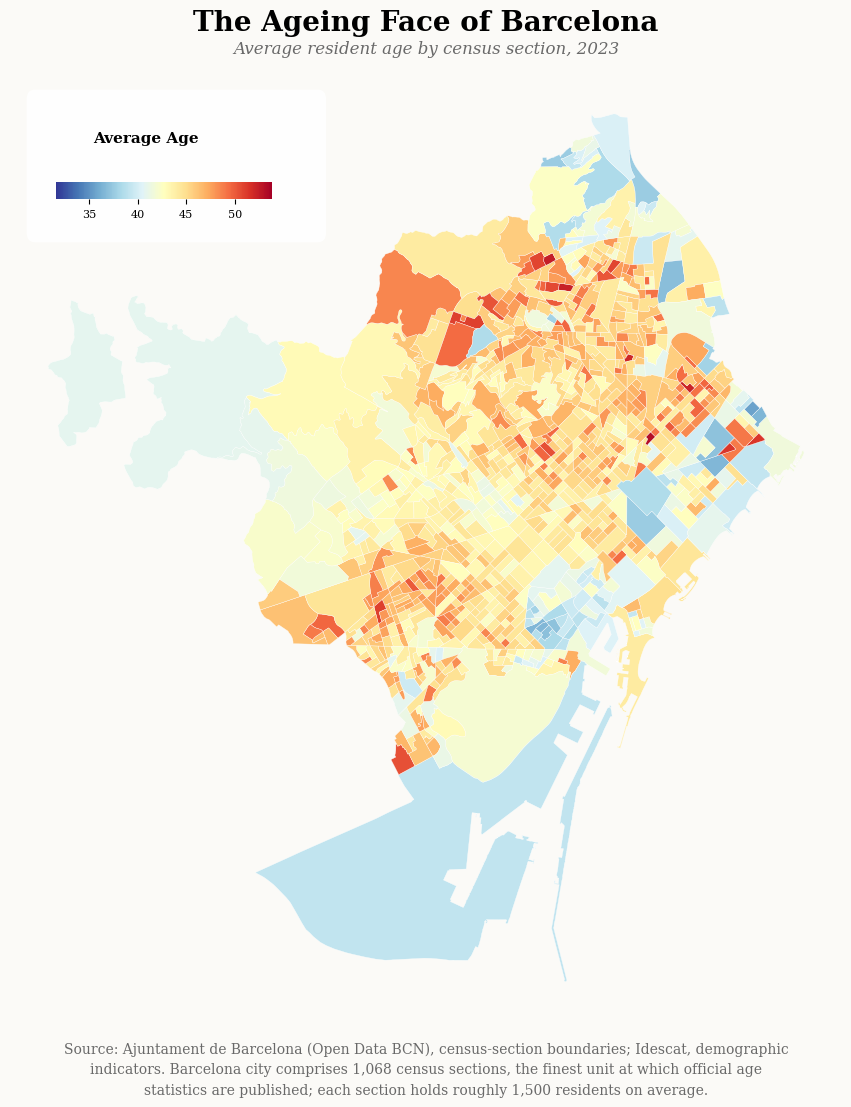

In [5]:
plt.rcParams["font.family"] = "Serif"

fig, ax = plt.subplots(figsize=(10, 11.5))
fig.patch.set_facecolor("#fbfaf7")
ax.set_facecolor("#fbfaf7")

vmin, vmax = age_df["avg_age"].min(), age_df["avg_age"].max()  # fixed to the full 9-year range so this map is directly comparable to the panel and animation below
cmap = "RdYlBu_r"

# continuous fill (no binning) -- lets subtle within-neighborhood variation show through
map_df.plot(
    column="avg_age",
    cmap=cmap,
    vmin=vmin, vmax=vmax,
    edgecolor="white",
    linewidth=0.25,
    ax=ax,
    legend=False,
)
ax.set_axis_off()

# legend card, top-left, directly under the title block
card = FancyBboxPatch(
    (0.03, 0.83), 0.34, 0.14,
    transform=ax.transAxes, boxstyle="round,pad=0.01,rounding_size=0.01",
    facecolor="white", edgecolor="none", alpha=0.88, zorder=5,
)
ax.add_patch(card)

cax = ax.inset_axes([0.055, 0.865, 0.26, 0.018])
cax.set_zorder(6)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=8)
cb.outline.set_visible(False)
ax.text(0.1, 0.925, "Average Age", transform=ax.transAxes, fontsize=11,
        color="black", family="Serif", weight="bold", zorder=6)

# title + subtitle, centered
fig.text(0.5, 0.955, "The Ageing Face of Barcelona", fontsize=20, weight="bold",
          ha="center", family="Serif")
fig.text(0.5, 0.935, f"Average resident age by census section, {YEAR}", fontsize=12,
          ha="center", style="italic", color="dimgray", family="Serif")

# caption, larger font, wrapped to span the full figure width
caption_raw = ("Source: Ajuntament de Barcelona (Open Data BCN), census-section boundaries; Idescat, "
               "demographic indicators. Barcelona city comprises 1,068 census sections, the finest unit "
               "at which official age statistics are published; each section holds roughly 1,500 residents "
               "on average.")
caption = "\n".join(textwrap.wrap(caption_raw, width=100))
fig.text(0.5, 0.03, caption, fontsize=10, ha="center", color="dimgray",
          family="Serif", linespacing=1.6)

plt.subplots_adjust(top=0.92, bottom=0.09, left=0.02, right=0.98)
plt.savefig(f"{OUT_DIR}/bcn_avg_age_{YEAR}.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 5. A complementary view: share of population aged 65+ (2023)

Average age summarizes an entire distribution in a single number, which can
mask bimodal patterns - a young immigrant population living alongside an
ageing native population within the same section, for instance. The share of
residents aged 65 or over is a more direct proxy for demand on elderly-care
services, accessible housing, and age-friendly mobility design. We reuse the
same section-level pipeline, only swapping the indicator, and add a general
`load_indicator()` helper so later sections can pull in population and other
indicators the same way.

In [6]:
def load_indicator(indicator, stats_raw):
    """Pull one demographic indicator for all Barcelona-city census sections.

    Matches on the exact concept name (not a substring of entry['Nombre']),
    since several indicator names contain one another as substrings
    (e.g. "Población" is contained in "Porcentaje de población menor de 18 años").
    """
    rows = []
    for entry in stats_raw:
        concept = next((m for m in entry["MetaData"] if m["T3_Variable"] == "Conceptos demógraficos"), None)
        if concept is None or concept["Nombre"] != indicator:
            continue
        section = next((m for m in entry["MetaData"] if m["T3_Variable"] == "Secciones"), None)
        if section is None or not section["Codigo"].startswith("08019"):
            continue
        for obs in entry["Data"]:
            rows.append({"section_code": section["Codigo"], "year": obs["Anyo"], "value": obs["Valor"]})
    return pd.DataFrame(rows)


elderly_df = load_indicator("Porcentaje de población de 65 y más años", stats_raw)
elderly_df = elderly_df.rename(columns={"value": "pct_65plus"})

elderly_2023 = geo.merge(elderly_df[elderly_df["year"] == YEAR][["section_code", "pct_65plus"]],
                          on="section_code", how="left")

print(f"{len(elderly_2023)} sections | {elderly_2023['pct_65plus'].isna().sum()} missing values for {YEAR}")
elderly_2023["pct_65plus"].describe()

1068 sections | 0 missing values for 2023


,pct_65plus
count,1068.000000
mean,22.007491
std,5.257795
min,6.800000
25%,18.900000
50%,21.800000
75%,25.325000
max,40.900000


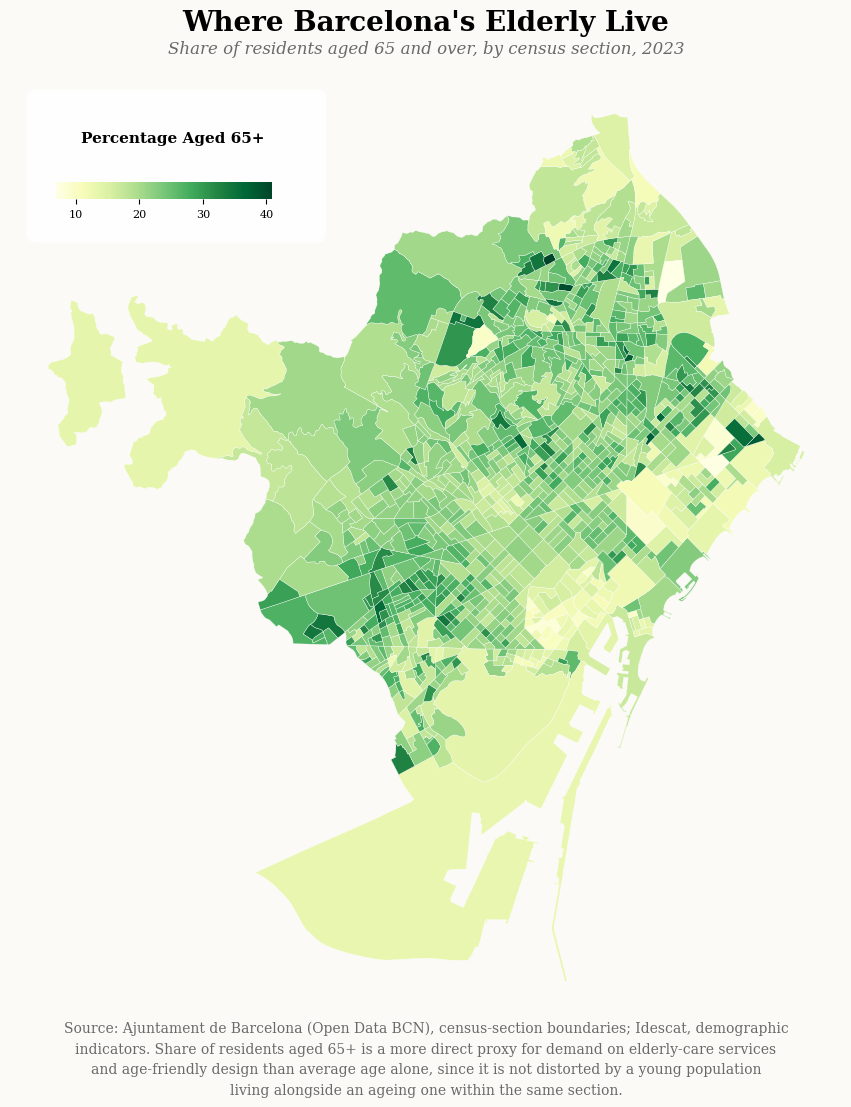

In [7]:
plt.rcParams["font.family"] = "Serif"

fig, ax = plt.subplots(figsize=(10, 11.5))
fig.patch.set_facecolor("#fbfaf7")
ax.set_facecolor("#fbfaf7")

vmin, vmax = elderly_2023["pct_65plus"].min(), elderly_2023["pct_65plus"].max()
cmap = "YlGn"

elderly_2023.plot(
    column="pct_65plus",
    cmap=cmap,
    vmin=vmin, vmax=vmax,
    edgecolor="white",
    linewidth=0.25,
    ax=ax,
    legend=False,
)
ax.set_axis_off()

# legend card, top-left, directly under the title block (same layout as the avg-age map)
card = FancyBboxPatch(
    (0.03, 0.83), 0.34, 0.14,
    transform=ax.transAxes, boxstyle="round,pad=0.01,rounding_size=0.01",
    facecolor="white", edgecolor="none", alpha=0.88, zorder=5,
)
ax.add_patch(card)

cax = ax.inset_axes([0.055, 0.865, 0.26, 0.018])
cax.set_zorder(6)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=8)
cb.outline.set_visible(False)
ax.text(0.085, 0.925, "Percentage Aged 65+", transform=ax.transAxes, fontsize=11,
        color="black", family="Serif", weight="bold", zorder=6)

fig.text(0.5, 0.955, "Where Barcelona's Elderly Live", fontsize=20, weight="bold",
          ha="center", family="Serif")
fig.text(0.5, 0.935, f"Share of residents aged 65 and over, by census section, {YEAR}",
          fontsize=12, ha="center", style="italic", color="dimgray", family="Serif")

caption_raw = ("Source: Ajuntament de Barcelona (Open Data BCN), census-section boundaries; Idescat, "
               "demographic indicators. Share of residents aged 65+ is a more direct proxy for demand on "
               "elderly-care services and age-friendly design than average age alone, since it is not "
               "distorted by a young population living alongside an ageing one within the same section.")
caption = "\n".join(textwrap.wrap(caption_raw, width=100))
fig.text(0.5, 0.03, caption, fontsize=10, ha="center", color="dimgray", family="Serif", linespacing=1.6)

plt.subplots_adjust(top=0.92, bottom=0.09, left=0.02, right=0.98)
plt.savefig(f"{OUT_DIR}/bcn_pct_65plus_{YEAR}.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

In [8]:
from scipy import stats

merged_2023 = (age_df[age_df["year"] == 2023][["section_code", "avg_age"]]
               .merge(elderly_df[elderly_df["year"] == 2023][["section_code", "pct_65plus"]], on="section_code")
               .merge(geo[["section_code", "nom_districte", "nom_barri"]], on="section_code"))

r, p = stats.pearsonr(merged_2023["avg_age"], merged_2023["pct_65plus"])
print(f"Correlation between average age and 65+ share across sections, 2023: r = {r:.2f} (p = {p:.1e})")

slope, intercept, _, _, _ = stats.linregress(merged_2023["avg_age"], merged_2023["pct_65plus"])
merged_2023["predicted_pct65"] = slope * merged_2023["avg_age"] + intercept
merged_2023["residual"] = merged_2023["pct_65plus"] - merged_2023["predicted_pct65"]

print()
print("Sections where the 65+ share is higher than average age alone predicts:")
display(merged_2023.sort_values("residual", ascending=False).head(5)
        [["nom_barri", "nom_districte", "avg_age", "pct_65plus", "residual"]].round(1))

print()
print("Sections where the 65+ share is lower than average age alone predicts:")
display(merged_2023.sort_values("residual").head(5)
        [["nom_barri", "nom_districte", "avg_age", "pct_65plus", "residual"]].round(1))

Correlation between average age and 65+ share across sections, 2023: r = 0.95 (p = 0.0e+00)

Sections where the 65+ share is higher than average age alone predicts:


,nom_barri,nom_districte,avg_age,pct_65plus,residual
920,la Sagrera,Sant Andreu,48.9,36.3,6.1
1032,Sant Martí de Provençals,Sant Martí,49.1,36.4,5.8
439,Sant Gervasi - la Bonanova,Sarrià-Sant Gervasi,44.1,26.5,5.4
354,les Corts,Les Corts,47.3,32.3,5.1
520,la Salut,Gràcia,48.2,34.0,5.1



Sections where the 65+ share is lower than average age alone predicts:


,nom_barri,nom_districte,avg_age,pct_65plus,residual
263,la Marina de Port,Sants-Montjuïc,47.1,20.6,-6.2
1018,Provençals del Poblenou,Sant Martí,46.2,19.9,-5.2
743,Porta,Nou Barris,49.1,25.9,-4.7
30,la Barceloneta,Ciutat Vella,44.1,17.0,-4.1
253,la Marina de Port,Sants-Montjuïc,46.7,22.1,-3.9


The two measures are very strongly correlated (r = 0.95), which is expected
since 65+ share is one of the components that determines average age. The
value of mapping both, rather than average age alone, shows up in the small
number of sections where they diverge. La Marina de Port, already flagged
in Sections 7 and 9 as one of the more persistently older sections in the
city by average age, has a 65+ share noticeably lower than that average age
would predict. That is consistent with an age distribution skewed toward
the 50 to 64 range rather than toward 65 and over specifically, a pattern
average age alone cannot distinguish from an equivalent share of genuinely
elderly residents. This is exactly the bimodal-distribution concern raised
in Section 5: two sections can share an average age while looking
completely different in terms of who actually lives there.

## 6. How has the city aged? 2015 vs. 2019 vs. 2021 vs. 2023

A 2x2 panel lets us compare four snapshots directly: two years before the
pandemic (2015, 2019), one during it (2021), and the most recent year
(2023). All four panels share a single color scale, computed across just
these four years, so a section getting redder over time is ageing faster
than the city as a whole - the panels are not each independently
re-normalized, which would hide real change behind a shifting scale.

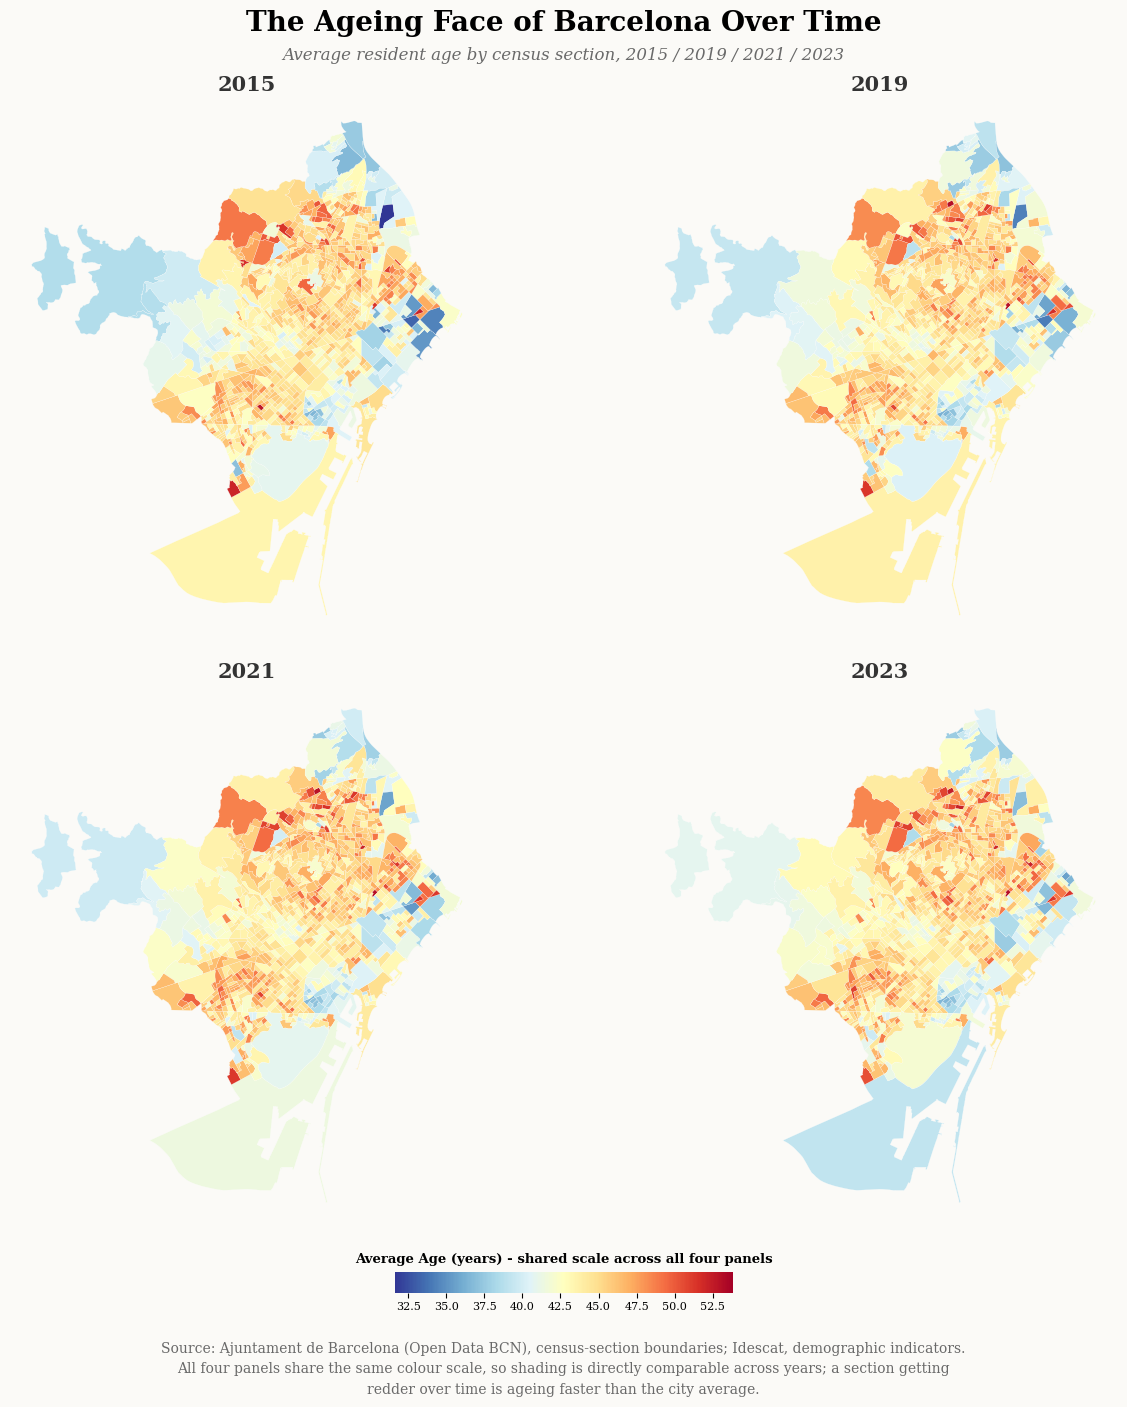

In [9]:
years_compare = [2015, 2019, 2021, 2023]
vmin, vmax = age_df["avg_age"].min(), age_df["avg_age"].max()  # full 9-year range, matches the single map and the animation
cmap = "RdYlBu_r"

plt.rcParams["font.family"] = "Serif"

fig, axes = plt.subplots(2, 2, figsize=(13, 14.5))
fig.patch.set_facecolor("#fbfaf7")

for ax, yr in zip(axes.flat, years_compare):
    ax.set_facecolor("#fbfaf7")
    yr_df = geo.merge(age_df[age_df["year"] == yr][["section_code", "avg_age"]], on="section_code", how="left")
    yr_df.plot(column="avg_age", cmap=cmap, vmin=vmin, vmax=vmax,
               edgecolor="white", linewidth=0.15, ax=ax, legend=False)
    ax.set_axis_off()
    ax.set_title(str(yr), fontsize=15, weight="bold", family="Serif", color="#333333", pad=4)

fig.text(0.5, 0.965, "The Ageing Face of Barcelona Over Time", fontsize=20, weight="bold",
          ha="center", family="Serif")
fig.text(0.5, 0.945, "Average resident age by census section, 2015 / 2019 / 2021 / 2023",
          fontsize=12, ha="center", style="italic", color="dimgray", family="Serif")

cax = fig.add_axes([0.37, 0.095, 0.26, 0.014])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=8)
cb.outline.set_visible(False)
fig.text(0.5, 0.115, "Average Age (years) - shared scale across all four panels",
          fontsize=9.5, ha="center", family="Serif", color="black", weight="bold")

caption_raw = ("Source: Ajuntament de Barcelona (Open Data BCN), census-section boundaries; Idescat, demographic "
               "indicators. All four panels share the same colour scale, so shading is directly comparable "
               "across years; a section getting redder over time is ageing faster than the city average.")
caption = "\n".join(textwrap.wrap(caption_raw, width=110))
fig.text(0.5, 0.025, caption, fontsize=10, ha="center", color="dimgray", family="Serif", linespacing=1.6)

plt.subplots_adjust(top=0.92, bottom=0.14, left=0.02, right=0.98, wspace=0.03, hspace=0.08)
plt.savefig(f"{OUT_DIR}/bcn_avg_age_comparison.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 7. Where is Barcelona ageing the most?

Two rankings, computed for the same four comparison years:

- **Top 10 census sections** by average age (the finest unit available).
- **Top 3 districts** by *population-weighted* average age - a simple
  mean across a district's sections would let a handful of tiny sections
  distort the ranking, so each section's average age is weighted by its
  own population before aggregating.

Laying both out with years as columns makes it possible to read off
directly whether the same places stay at the top or the ranking reshuffles.

In [10]:
pop_df = load_indicator("Población", stats_raw).rename(columns={"value": "population"})

merged = (age_df.merge(pop_df, on=["section_code", "year"])
                 .merge(geo[["section_code", "nom_districte", "nom_barri"]], on="section_code"))

def weighted_avg_age(g):
    return (g["avg_age"] * g["population"]).sum() / g["population"].sum()

district_age = (merged.groupby(["year", "nom_districte"])
                       .apply(weighted_avg_age)
                       .rename("weighted_avg_age")
                       .reset_index())

# --- top 3 districts per year (population-weighted) ---
top_districts = (district_age[district_age["year"].isin(years_compare)]
                  .sort_values(["year", "weighted_avg_age"], ascending=[True, False])
                  .groupby("year").head(3))
top_districts["rank"] = top_districts.groupby("year")["weighted_avg_age"].rank(ascending=False, method="first").astype(int)
top_districts["label"] = top_districts["nom_districte"] + " (" + top_districts["weighted_avg_age"].round(1).astype(str) + ")"
districts_wide = top_districts.pivot(index="rank", columns="year", values="label")
districts_wide.index.name = "District rank"

# --- top 10 census sections per year ---
top_sections = (age_df[age_df["year"].isin(years_compare)]
                 .merge(geo[["section_code", "nom_districte", "nom_barri"]], on="section_code")
                 .sort_values(["year", "avg_age"], ascending=[True, False])
                 .groupby("year").head(10))
top_sections["rank"] = top_sections.groupby("year")["avg_age"].rank(ascending=False, method="first").astype(int)
top_sections["label"] = top_sections["nom_barri"] + " (" + top_sections["avg_age"].round(1).astype(str) + ")"
sections_wide = top_sections.pivot(index="rank", columns="year", values="label")
sections_wide.index.name = "Section rank"

print("Top 3 districts, population-weighted average age (years)")
display(districts_wide)
print()
print("Top 10 census sections, average age (years) - labelled by neighborhood")
display(sections_wide)

Top 3 districts, population-weighted average age (years)


/tmp/ipykernel_1675/4151752181.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_avg_age)


year,2015,2019,2021,2023
District rank,,,,
1,Les Corts (45.6),Les Corts (46.0),Les Corts (46.4),Les Corts (46.3)
2,Horta-Guinardó (45.1),Horta-Guinardó (45.0),Horta-Guinardó (45.3),Horta-Guinardó (45.1)
3,Eixample (44.8),Eixample (44.8),Eixample (44.9),Sant Andreu (44.9)



Top 10 census sections, average age (years) - labelled by neighborhood


year,2015,2019,2021,2023
Section rank,,,,
1,la Nova Esquerra de l'Eixample (52.6),Canyelles (53.1),el Clot (53.0),el Clot (53.1)
2,Diagonal Mar i el Front Marítim del Poblenou (...,el Clot (53.0),Canyelles (52.9),Canyelles (52.4)
3,la Marina de Port (52.1),Diagonal Mar i el Front Marítim del Poblenou (...,la Sagrera (52.1),la Guineueta (52.2)
4,Sant Genís dels Agudells (51.6),la Sagrera (51.4),la Guineueta (51.5),la Verneda i la Pau (52.1)
5,Horta (51.4),la Marina de Port (51.3),Diagonal Mar i el Front Marítim del Poblenou (...,la Sagrera (51.9)
6,el Clot (51.4),la Prosperitat (51.2),la Prosperitat (51.3),el Besòs i el Maresme (51.3)
7,la Verneda i la Pau (50.9),la Guineueta (51.0),la Marina de Port (51.2),Diagonal Mar i el Front Marítim del Poblenou (...
8,el Turó de la Peira (50.5),la Nova Esquerra de l'Eixample (50.8),el Besòs i el Maresme (51.2),les Corts (51.0)
9,la Sagrera (50.3),el Turó de la Peira (50.7),la Verneda i la Pau (51.2),la Vall d'Hebron (51.0)


**Reading the tables:** the district ranking is remarkably stable - Les
Corts and Horta-Guinardó hold the top two spots in every one of the four
years, and the weighted average age in Les Corts *rises* from 45.6 (2015) to
46.3 (2023) rather than converging toward the city mean. The third spot is
the only one that moves, from Eixample (2015–2021) to Sant Andreu (2023),
though by a narrow margin.

At the section level there is more turnover: a persistent core of ageing
neighborhoods reappears every year (el Clot, Canyelles, la Guineueta, la
Sagrera, la Verneda i la Pau - mostly in Sant Martí, Nou Barris and Sant
Andreu), consistent with structural rather than transient ageing. But
central, gentrifying sections like la Nova Esquerra de l'Eixample rank in
the top 10 only in 2015 and 2019 and then drop out, while les Corts and la
Vall d'Hebron newly enter the top 10 by 2023 - suggestive of demographic
turnover in the city center that outer, post-industrial districts are not
experiencing at the same pace. This is a descriptive pattern rather than a
causal claim; disentangling ageing-in-place from selective in/out-migration
would need cohort-level data this dataset doesn't contain.

## 8. Animating all nine years (2015–2023)

A static four-panel comparison necessarily skips five of the nine years.
The animation below cycles through every year, using the exact same visual
style as the 2023 map (same fonts, legend card, colour scale) so it reads as
a natural extension rather than a different figure. The colour scale is
fixed across all nine years - computed once from the full `age_df`, not
per-frame - for the same reason as the 2x2 panel: without a shared scale,
colour differences between frames would reflect the scale re-normalizing
rather than the city actually changing.

For efficiency, the map is drawn once and only the polygon colours and the
year in the subtitle are updated per frame, rather than re-drawing the whole
figure nine times.

Saved as an mp4 rather than a gif: gif files are capped at a 256-colour
palette, which visibly bands a continuous colour scale like this one once
compressed. Video keeps full colour fidelity, so a given shade means the
same value here as it does in every other map in this notebook.

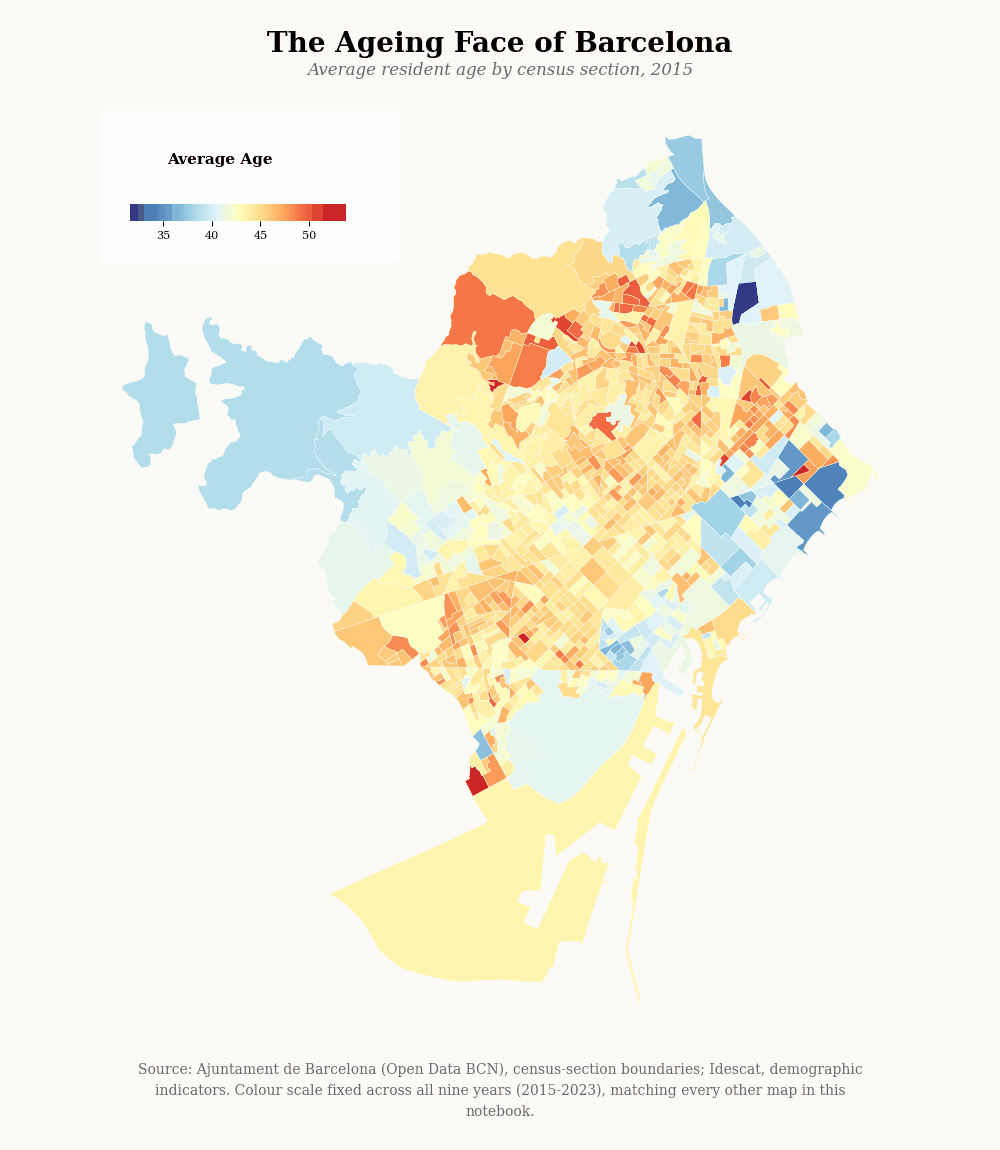

In [14]:
import matplotlib.animation as animation
from IPython.display import Image as IPImage

years_all = sorted(age_df["year"].unique())
vmin, vmax = age_df["avg_age"].min(), age_df["avg_age"].max()
cmap = "RdYlBu_r"

plt.rcParams["font.family"] = "Serif"
fig, ax = plt.subplots(figsize=(10, 11.5))
fig.patch.set_facecolor("#fbfaf7")

fig.text(0.5, 0.955, "The Ageing Face of Barcelona", fontsize=20, weight="bold",
          ha="center", family="Serif")
subtitle_txt = fig.text(0.5, 0.935, f"Average resident age by census section, {years_all[0]}",
                          fontsize=12, ha="center", style="italic", color="dimgray", family="Serif")

caption_raw = ("Source: Ajuntament de Barcelona (Open Data BCN), census-section boundaries; Idescat, "
               "demographic indicators. Colour scale fixed across all nine years (2015-2023), matching "
               "every other map in this notebook.")
caption = "\n".join(textwrap.wrap(caption_raw, width=100))
fig.text(0.5, 0.03, caption, fontsize=10, ha="center", color="dimgray", family="Serif", linespacing=1.6)

plt.subplots_adjust(top=0.92, bottom=0.09, left=0.02, right=0.98)

def draw_frame(yr):
    # redraw from scratch each frame, exactly like the static maps do, rather than
    # updating a fixed PatchCollection: two sections (la Marina del Prat Vermell and
    # the Vallvidrera / Tibidabo area) are MultiPolygons, which geopandas draws as
    # multiple patches. Updating a collection's colour array in place assumes one
    # patch per section, which silently misaligns colours onto the wrong polygons
    # for every section after those two. A full redraw does not have that problem.
    ax.clear()
    ax.set_facecolor("#fbfaf7")
    yr_df = geo.merge(age_df[age_df["year"] == yr][["section_code", "avg_age"]], on="section_code", how="left")
    yr_df.plot(column="avg_age", cmap=cmap, vmin=vmin, vmax=vmax,
               edgecolor="white", linewidth=0.25, ax=ax, legend=False)
    ax.set_axis_off()

    card = FancyBboxPatch(
        (0.03, 0.83), 0.34, 0.14,
        transform=ax.transAxes, boxstyle="round,pad=0.01,rounding_size=0.01",
        facecolor="white", edgecolor="none", alpha=0.88, zorder=5,
    )
    ax.add_patch(card)

    # ax.clear() also removes any inset axes, so the colour bar is rebuilt each frame too
    cax = ax.inset_axes([0.055, 0.865, 0.26, 0.018])
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
    cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cb.ax.tick_params(labelsize=8)
    cb.outline.set_visible(False)
    ax.text(0.1, 0.925, "Average Age", transform=ax.transAxes, fontsize=11,
            color="black", family="Serif", weight="bold", zorder=6)

    subtitle_txt.set_text(f"Average resident age by census section, {yr}")

def animate(i):
    draw_frame(years_all[i])
    return ax.get_children()

anim = animation.FuncAnimation(fig, animate, frames=len(years_all), interval=900, blit=False, repeat=True)

#save it as a .gif

anim.save(f"{OUT_DIR}/bcn_avg_age_animation.gif", writer="pillow", fps=1.1)
plt.close(fig)

IPImage(filename=f"{OUT_DIR}/bcn_avg_age_animation.gif")

## 9. Where has ageing moved fastest? 2015 → 2023 change

Levels and rankings (§7) show *where* the oldest sections are, but not
*where age is changing fastest* - a section can be young in absolute terms
and still be ageing rapidly. Here we map the raw change,
`avg_age(2023) − avg_age(2015)`, per census section, on a diverging scale
centred at zero: red sections aged faster than a flat trend would predict,
blue sections got younger over the period (plausible with new construction,
turnover toward younger renters, or household composition change).

1068 sections | 0 missing | mean change +0.32 years


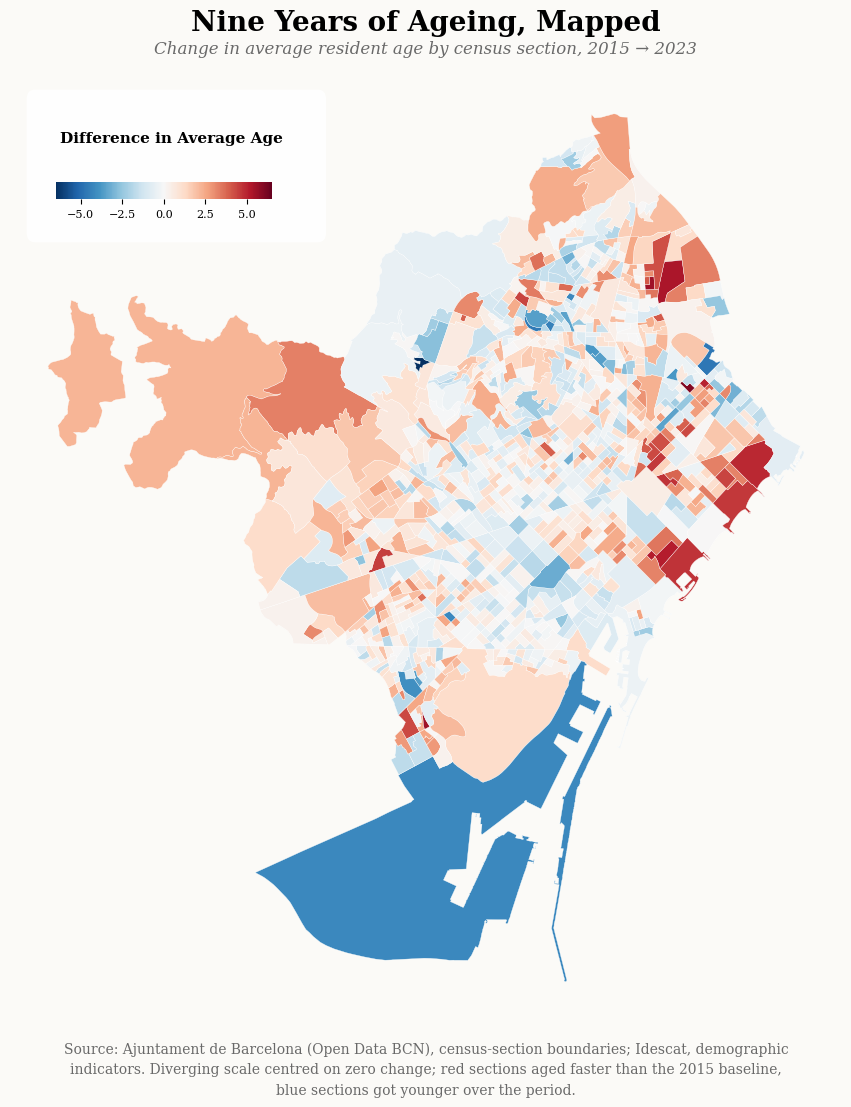

In [12]:
change_df = (age_df[age_df["year"] == 2023][["section_code", "avg_age"]].rename(columns={"avg_age": "age_2023"})
             .merge(age_df[age_df["year"] == 2015][["section_code", "avg_age"]].rename(columns={"avg_age": "age_2015"}),
                    on="section_code"))
change_df["delta"] = change_df["age_2023"] - change_df["age_2015"]

change_map = geo.merge(change_df[["section_code", "delta"]], on="section_code", how="left")
print(f"{len(change_map)} sections | {change_map['delta'].isna().sum()} missing | "
      f"mean change {change_map['delta'].mean():+.2f} years")

vabs = change_map["delta"].abs().max()  # symmetric range so zero sits at the centre of the scale
cmap = "RdBu_r"

plt.rcParams["font.family"] = "Serif"
fig, ax = plt.subplots(figsize=(10, 11.5))
fig.patch.set_facecolor("#fbfaf7")
ax.set_facecolor("#fbfaf7")

change_map.plot(column="delta", cmap=cmap, vmin=-vabs, vmax=vabs,
                 edgecolor="white", linewidth=0.25, ax=ax, legend=False)
ax.set_axis_off()

card = FancyBboxPatch(
    (0.03, 0.83), 0.34, 0.14,
    transform=ax.transAxes, boxstyle="round,pad=0.01,rounding_size=0.01",
    facecolor="white", edgecolor="none", alpha=0.88, zorder=5,
)
ax.add_patch(card)

cax = ax.inset_axes([0.055, 0.865, 0.26, 0.018])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=-vabs, vmax=vabs))
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=8)
cb.outline.set_visible(False)
ax.text(0.06, 0.925, "Difference in Average Age", transform=ax.transAxes, fontsize=11,
        color="black", family="Serif", weight="bold", zorder=6)

fig.text(0.5, 0.955, "Nine Years of Ageing, Mapped", fontsize=20, weight="bold",
          ha="center", family="Serif")
fig.text(0.5, 0.935, "Change in average resident age by census section, 2015 → 2023",
          fontsize=12, ha="center", style="italic", color="dimgray", family="Serif")

caption_raw = ("Source: Ajuntament de Barcelona (Open Data BCN), census-section boundaries; Idescat, "
               "demographic indicators. Diverging scale centred on zero change; red sections aged faster "
               "than the 2015 baseline, blue sections got younger over the period.")
caption = "\n".join(textwrap.wrap(caption_raw, width=100))
fig.text(0.5, 0.03, caption, fontsize=10, ha="center", color="dimgray", family="Serif", linespacing=1.6)

plt.subplots_adjust(top=0.92, bottom=0.09, left=0.02, right=0.98)
plt.savefig(f"{OUT_DIR}/bcn_avg_age_change_2015_2023.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

In [13]:
movers = change_df.merge(geo[["section_code", "nom_districte", "nom_barri"]], on="section_code")

fastest_ageing = movers.sort_values("delta", ascending=False).head(5)
fastest_ageing = fastest_ageing[["nom_barri", "nom_districte", "age_2015", "age_2023", "delta"]]

fastest_deageing = movers.sort_values("delta", ascending=True).head(5)
fastest_deageing = fastest_deageing[["nom_barri", "nom_districte", "age_2015", "age_2023", "delta"]]

print("5 fastest-ageing census sections, 2015 → 2023")
display(fastest_ageing.round(1))
print()
print("5 fastest-de-ageing (getting younger) census sections, 2015 → 2023")
display(fastest_deageing.round(1))

5 fastest-ageing census sections, 2015 → 2023


,nom_barri,nom_districte,age_2015,age_2023,delta
1051,la Verneda i la Pau,Sant Martí,46.1,52.1,6.0
263,la Marina de Port,Sants-Montjuïc,41.6,47.1,5.5
852,Sant Andreu,Sant Andreu,36.8,42.3,5.5
833,el Bon Pastor,Sant Andreu,31.6,36.9,5.3
973,la Vila Olímpica del Poblenou,Sant Martí,40.3,45.4,5.1



5 fastest-de-ageing (getting younger) census sections, 2015 → 2023


,nom_barri,nom_districte,age_2015,age_2023,delta
677,Sant Genís dels Agudells,Horta-Guinardó,51.6,45.1,-6.5
1058,la Verneda i la Pau,Sant Martí,42.7,38.0,-4.7
754,el Turó de la Peira,Nou Barris,48.0,43.4,-4.6
752,el Turó de la Peira,Nou Barris,45.9,41.5,-4.4
186,la Nova Esquerra de l'Eixample,Eixample,52.6,48.4,-4.2


**Reading the change map:** the citywide mean shift is only +0.3 years, so
most of the map sits close to the neutral colour - the interesting signal is
in the small number of sections at either extreme (up to +6.0 and −6.5
years). The fastest-ageing sections concentrate in Sant Martí and Sant
Andreu, several of which were still in active urban redevelopment through
this period (former industrial land converted to housing), which can push
average age up sharply as an initial residential cohort ages in place with
comparatively little turnover.

One pattern worth flagging rather than glossing over: **la Verneda i la Pau
appears in both the fastest-ageing and fastest-de-ageing lists** - one
section there gained 6.0 years, another lost 4.7. Since a neighborhood name
can span several distinct census sections, this is a reminder that
"la Verneda i la Pau is ageing" is not a well-formed claim at this level of
granularity; the section, not the neighborhood, is the unit that is
actually moving, and neighboring sections can diverge sharply from one
another. This is itself an argument for the census-section-level approach
this notebook takes throughout, rather than aggregating to neighborhood or
district before mapping.

## 10. Summary

Four findings stand out from this notebook, read together rather than
section by section.

**Ageing is not uniform within the city, and municipal or even district
averages hide most of the interesting variation.** The citywide average age
was 44.3 years in 2023, but individual census sections range from 35.6 to
53.1, a spread of over 17 years within a single municipality. Section 9's
change map shows the same is true of the pace of ageing: while the city
average moved by only 0.3 years over 2015 to 2023, some sections moved by
more than six years in either direction. A policy built around the
municipal or district figure would misjudge most of the city's actual
sections in both directions.

**Where the city is oldest has been remarkably stable, but it is not
static.** Les Corts and Horta-Guinardó held the top two spots in the
district ranking every single year from 2015 to 2023 (Section 7), and Les
Corts' weighted average age has actually risen over that period rather than
converging to the city mean. At the same time, the third-ranked district
changed, and the section-level ranking showed real turnover, with
gentrifying central sections dropping out of the oldest 10 as outer,
post-industrial districts (Sant Marti, Nou Barris, Sant Andreu) moved in.
Persistence at the top does not mean nothing is changing underneath it.

**A single section can be ageing and getting younger at the same time,
depending on which part of it you look at.** La Verneda i la Pau appears in
both the fastest-ageing and fastest-de-ageing lists in Section 9, because
different census sections that share that neighborhood name moved in
opposite directions. This is the practical argument for the
census-section-level approach used throughout this notebook: neighborhood
or district-level statistics would have averaged this away and reported a
single, misleading figure.

**Average age and the 65+ share mostly agree, but not always, and the
disagreement is informative.** The two measures correlate at r = 0.95
across sections in 2023, so for most of the city either one is a fine proxy
for the other. Where they diverge, as in la Marina de Port, it signals a
population that is older on average without necessarily having a
correspondingly large elderly share, which matters for the specific kind of
service planning discussed in the introduction; a section that is ageing
toward 65 needs different provision than one that is already there.

Taken together, this supports the argument made at the start of the
notebook: age-related public services and legislation planned from
municipal or even district-level statistics would be calibrated to a
resident who, in most of Barcelona's 1,068 census sections, does not
actually exist.